# Lab 25 — Spread Spectrum, CDMA and a GPS Receiver from Scratch

**Companion to Chapter 18** (*Spread Spectrum, CDMA and GNSS/GPS*).
**Time needed:** about 2 hours. **Difficulty:** core → advanced.

Spreading a signal over a bandwidth far larger than its data rate looks wasteful, and it buys four things that nothing else does:
resistance to jamming, the ability to resolve and combine multipath, many users sharing one band by code, and precise timing. The
Global Positioning System uses all four to deliver a signal 20 dB *below* the noise to billions of receivers, each of which measures
its distance to satellites 20 000 km away to within metres. This lab goes from shift registers to a position fix. You will build
m-sequences, Gold and Kasami codes and check their correlations; spread and despread BPSK against a tone jammer; combine multipath with a
Rake receiver; watch the near–far problem break a CDMA uplink and fix it with multiuser detection; then generate a multi-satellite GPS L1
C/A signal buried in noise, acquire it with an FFT search, track it with a DLL and an FLL-assisted Costas loop, read the navigation bits,
and solve for position. Everything comes from `commlib/spread.py`, the module behind every data figure of Chapter 18.

### What you will learn
1. Generate m-sequences and Gold/Kasami families, the GPS C/A codes, and verify their correlation properties.
2. Quantify processing gain and jamming margin; simulate DSSS against a tone jammer.
3. Resolve and combine multipath with a Rake receiver and measure its diversity gain.
4. See the near–far problem, power control and multiuser detection in a synchronous CDMA uplink; compute IS-95 capacity.
5. Acquire GPS signals (code phase × Doppler search) and predict the detection probability.
6. Track code and carrier, demodulate the 50 b/s data, and compute a least-squares position fix and its DOP.

### Prerequisites
Lab 4 (PLLs, timing loops), Lab 5 (fading), Lab 10 (diversity). Chapter 18.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Shift registers, m-sequences, Gold and Kasami codes, GPS C/A | |
| 2 | DSSS, processing gain and jamming | yes |
| 3 | Multipath and the Rake receiver | |
| 4 | CDMA: near–far, power control, multiuser detection, capacity | yes |
| 5 | GPS: the signal below the noise, and acquisition | yes |
| 6 | Tracking: DLL, Costas PLL and navigation bits | |
| 7 | The position fix, DOP, the ionosphere and jammers | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import spread as sp
from commlib import labkit as lk

rng = lk.setup(seed=25, lab="25")

Lab 25 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 25


## 1. Shift registers, m-sequences, Gold and Kasami codes, GPS C/A

A linear feedback shift register with a **primitive** characteristic polynomial of degree $m$ cycles through all $2^m-1$ nonzero states:
its output is an **m-sequence**, with $2^{m-1}$ ones, runs like a fair coin, and a two-valued periodic autocorrelation
$R(0)=N$, $R(k\ne0)=-1$ (chips mapped $0\to+1$, $1\to-1$). Chapter 18's hand example: $x^3+x+1$ from 001 gives 0010111.

Many users need many codes with low **cross**-correlation. **Gold** codes (pairs of preferred m-sequences XORed at every relative shift)
give $2^m+1$ codes with three-valued cross-correlation $\{-1, -t(m), t(m)-2\}$; the small **Kasami** set gives fewer codes with lower peaks.
The GPS C/A codes are Gold codes of length 1023 built from two 10-stage registers (IS-GPS-200); PRN 1 starts 1100100000.

,
x^3 + x + 1 from 001,00101110010111
periodic autocorrelation,[ 7 -1 -1 -1 -1 -1 -1]
"GPS PRN 1, first 10 chips",1100100000


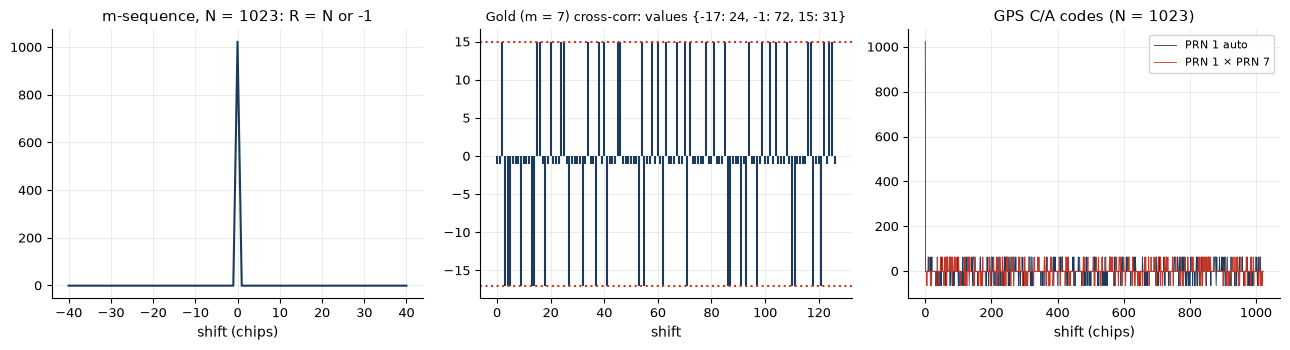

family,codes,length,peak |cross-corr| (measured),theory
"Gold, m = 7",129,127,17,17
"Gold, m = 10 (C/A size)",1025,1023,65,65
"small Kasami, m = 8",16,255,17,17
GPS C/A (4 pairs),32,1023,65,65


In [3]:
m3 = sp.lfsr([3, 1, 0], 14, init=[0, 0, 1])
c7 = sp.bipolar(m3[:7])
lk.table([["x^3 + x + 1 from 001", "".join(map(str, m3))], ["periodic autocorrelation", str(sp.pcorr(c7).round().astype(int))],
          ["GPS PRN 1, first 10 chips", "".join(map(str, sp.gps_ca_code(1)[:10]))]], ["", ""])

f, ax = lk.fig((13, 3.6), 1, 3)
u = sp.bipolar(sp.msequence(10))
ax[0].plot(np.arange(-40, 41), np.roll(sp.pcorr(u), 40)[:81], color=lk.NAVY)
ax[0].set_xlabel("shift (chips)"); ax[0].set_title(f"m-sequence, N = {len(u)}: R = N or -1")
G = sp.bipolar(sp.gold_codes(7))
cc = sp.pcorr(G[2], G[9])
vals, cnts = np.unique(np.round(cc).astype(int), return_counts=True)
ax[1].stem(np.arange(len(cc)), cc, markerfmt=" ", basefmt=" ")
ax[1].axhline(sp.gold_bound(7) - 2, color=lk.RED, ls=":"); ax[1].axhline(-sp.gold_bound(7), color=lk.RED, ls=":")
ax[1].set_xlabel("shift"); ax[1].set_title(f"Gold (m = 7) cross-corr: values {dict(zip(vals.tolist(), cnts.tolist()))}", fontsize=9)
ca = {p: sp.bipolar(sp.gps_ca_code(p)) for p in (1, 2, 7, 12)}
ax[2].plot(sp.pcorr(ca[1]), color=lk.NAVY, lw=0.6, label="PRN 1 auto")
ax[2].plot(sp.pcorr(ca[1], ca[7]), color=lk.RED, lw=0.6, label="PRN 1 × PRN 7")
ax[2].set_xlabel("shift (chips)"); ax[2].legend(fontsize=8); ax[2].set_title("GPS C/A codes (N = 1023)")
lk.show(f)
rows = []
for name, codes, m in [("Gold, m = 7", sp.gold_codes(7), 7), ("Gold, m = 10 (C/A size)", sp.gold_codes(10)[:20], 10),
                       ("small Kasami, m = 8", sp.kasami_small(8), 8)]:
    B = sp.bipolar(codes)
    peak = max(np.max(np.abs(sp.pcorr(B[i], B[j]))) for i in range(min(len(B), 12)) for j in range(i + 1, min(len(B), 12)))
    rows.append([name, len(sp.gold_codes(m)) if "Gold" in name else len(codes), B.shape[1], int(round(peak)),
                 sp.gold_bound(m) if "Gold" in name else 2 ** (m // 2) + 1])
caa = [int(round(np.max(np.abs(sp.pcorr(ca[a], ca[b]))))) for a, b in [(1, 2), (1, 7), (2, 12), (7, 12)]]
rows.append(["GPS C/A (4 pairs)", 32, 1023, max(caa), 65])
lk.table(rows, ["family", "codes", "length", "peak |cross-corr| (measured)", "theory"])

**What you should see.** The hand example 0010111 repeating, autocorrelation [7, −1, −1, …]; PRN 1 starting 1100100000. Gold cross-
correlations take only the three values {−1, −17, 15} for m = 7, and the C/A codes peak at 65 (−23.9 dB relative to 1023): the
isolation between satellites that a GPS receiver relies on, and why a very strong satellite can still mask a weak one.

### Try it yourself 1.1
What is the peak cross-correlation $t(m)$ of a Gold set of degree $m = 9$, and how many codes does it contain? Enter $t(9)$.

In [5]:
answer_1_1 = None
lk.check("1.1 Gold bound t(9)", answer_1_1, sp.gold_bound(9), atol=0)

[TODO] 1.1 Gold bound t(9): not attempted yet: replace the None with your answer

## 2. DSSS, processing gain and jamming

Multiplying each data bit by $G_p$ chips spreads the signal over $G_p$ times the bandwidth. The receiver multiplies by the same code:
the signal collapses back to its narrow bandwidth, while a narrowband jammer is spread *out* by the same factor and mostly filtered away.
A tone jammer of power $J$ acts like noise of density $J/G_p$ per bit: $E_b/N_0 \to (1/(E_b/N_0) + J/(G_pS))^{-1}$. The **jamming margin**
is $G_p - (E_b/N_0)_{\text{req}} - L$ dB.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

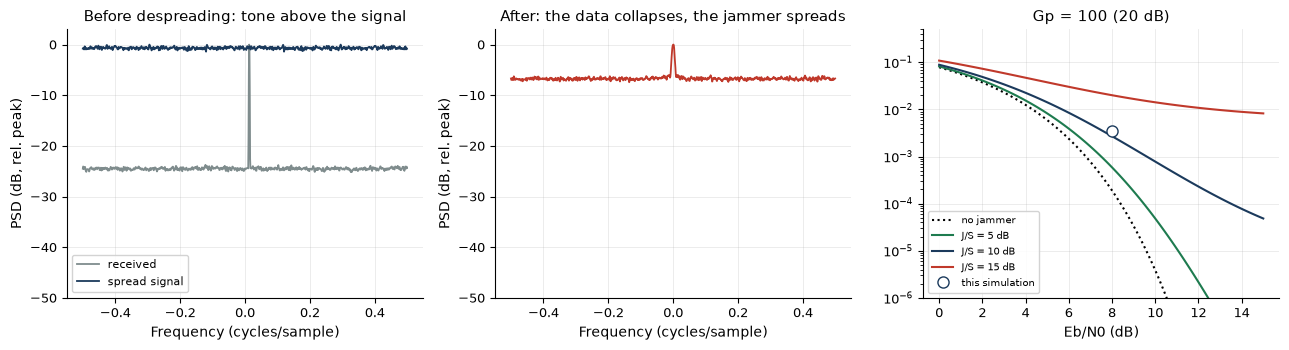

,
simulated BER,0.0035
theory,0.0027
"jamming margin for Eb/N0 req 9.6 dB, 2 dB loss (dB)",8.4


In [7]:
def dsss_demo(gp=100, jsr_db=10.0, ebn0_db=8.0):
    J = lk.undb(jsr_db)
    nb = 4000
    b = rng.choice([-1.0, 1.0], nb)
    pn = rng.choice([-1.0, 1.0], (nb, gp))
    tx = (b[:, None] * pn).ravel()
    k = np.arange(len(tx))
    jam = np.sqrt(J) * np.exp(1j * 2 * np.pi * 0.013 * k)
    N0 = gp / lk.undb(ebn0_db)
    n = np.sqrt(N0 / 2) * (rng.standard_normal(len(tx)) + 1j * rng.standard_normal(len(tx)))
    rx = tx + jam + n
    despread = rx * pn.ravel()
    z = np.real(despread.reshape(nb, gp).sum(axis=1))
    ber = np.mean(np.sign(z) != b)
    th = cl.qfunc(np.sqrt(2 / (1 / lk.undb(ebn0_db) + J / gp)))
    f, ax = lk.fig((13, 3.6), 1, 3)
    lk.psd(ax[0], rx[:200_000], nfft=1024, label="received", color=lk.GRAY)
    lk.psd(ax[0], tx[:200_000] + 0j, nfft=1024, label="spread signal", color=lk.NAVY)
    ax[0].set_title("Before despreading: tone above the signal"); ax[0].legend(fontsize=8); ax[0].set_ylim(-50, 3)
    lk.psd(ax[1], despread[:200_000], nfft=1024, label="after despreading", color=lk.RED)
    ax[1].set_title("After: the data collapses, the jammer spreads"); ax[1].set_ylim(-50, 3)
    eb = np.linspace(0, 15, 100)
    ax[2].semilogy(eb, cl.ber_bpsk(eb), "k:", label="no jammer")
    for jj, col in [(jsr_db - 5, lk.GREEN), (jsr_db, lk.NAVY), (jsr_db + 5, lk.RED)]:
        ax[2].semilogy(eb, cl.qfunc(np.sqrt(2 / (1 / lk.undb(eb) + lk.undb(jj) / gp))), color=col, label=f"J/S = {jj:g} dB")
    ax[2].semilogy(ebn0_db, max(ber, 1e-6), "o", color=lk.NAVY, mfc="white", ms=8, label="this simulation")
    ax[2].set_ylim(1e-6, 0.5); ax[2].set_xlabel("Eb/N0 (dB)"); ax[2].legend(fontsize=7.5); ax[2].set_title(f"Gp = {gp} ({lk.db(gp):.0f} dB)")
    lk.show(f)
    lk.table([["simulated BER", ber], ["theory", th], ["jamming margin for Eb/N0 req 9.6 dB, 2 dB loss (dB)",
                                                       sp.jamming_margin_db(lk.db(gp), 9.6, 2.0)]], ["", ""], fmt=".3g")

lk.interact(dsss_demo, gp=lk.choice([10, 31, 63, 100, 255, 1023], 100, "processing gain (chips/bit)"),
            jsr_db=lk.slider(10, -10, 30, 1, "jammer-to-signal ratio (dB)"), ebn0_db=lk.slider(8, 0, 15, 0.5, "Eb/N0 (dB)"))

**What you should see.** Before despreading the tone stands 10 dB above the whole spread signal; after despreading the data is a narrow
peak and the tone is a broad, low floor. With $G_p = 100$ (20 dB) and $J/S = 10$ dB the jammer costs only a fraction of a dB at moderate
$E_b/N_0$; at $J/S = 20$ dB it sets an error floor. Increase $G_p$ to 1023 (GPS C/A) and $J/S = 25$ dB becomes tolerable.

### Try it yourself 2.1
A 10.23 Mchip/s code carries 50 b/s of data. What is the processing gain in dB?

In [9]:
answer_2_1 = None
lk.check("2.1 processing gain, 10.23 Mchip/s / 50 b/s (dB)", answer_2_1, lk.db(10.23e6 / 50), atol=0.05)

[TODO] 2.1 processing gain, 10.23 Mchip/s / 50 b/s (dB): not attempted yet: replace the None with your answer

## 3. Multipath and the Rake receiver

Because the code's autocorrelation is a narrow spike, echoes delayed by more than a chip appear as separate peaks at the despreader. A
**Rake** receiver puts a correlator ("finger") on each, and combines them with maximal-ratio weights: $L$ independently fading paths give
diversity of order $L$. Below: a three-path channel at chip rate (delays 0, 3, 7 chips), the searcher output, and the BER of an
$L$-finger MRC Rake over equal-power Rayleigh paths (total energy fixed).

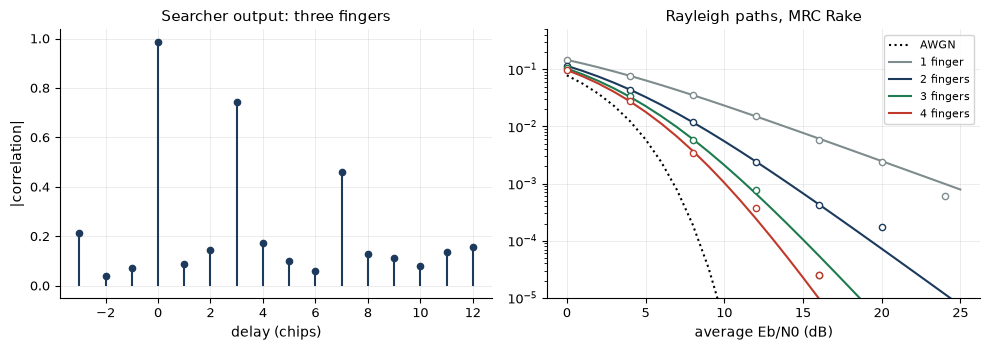

fingers,"BER (this static channel, 4000 bits)",collected energy (dB re path 1)
1,0.0132,0.00
2,0.0050,1.73
3,0.0025,2.29


In [11]:
Lc = 128
code = rng.choice([-1.0, 1.0], Lc)
delays, gains = np.array([0, 3, 7]), np.array([1.0, 0.7, 0.45]) * np.exp(1j * rng.uniform(0, 2 * np.pi, 3))
nsym = 4000
b = rng.choice([-1.0, 1.0], nsym)
tx = sp.spread(b, code)
rx = np.zeros(len(tx) + 10, complex)
for d, g in zip(delays, gains):
    rx[d:d + len(tx)] += g * tx
rx += 5.0 * (rng.standard_normal(len(rx)) + 1j * rng.standard_normal(len(rx)))   # about -17 dB per chip
lags = np.arange(-3, 13)
srch = [np.abs(np.vdot(sp.spread(b[1:41], code), rx[Lc + l:Lc + l + 40 * Lc])) / (40 * Lc) for l in lags]   # 40 known pilot symbols
rows = []
for fingers in ([0], [0, 3], [0, 3, 7]):
    idx = [list(delays).index(d) for d in fingers]
    zc, _ = sp.rake_combine(rx, code, nsym, fingers, gains[idx])
    rows.append([len(fingers), np.mean(np.sign(zc.real) != b), lk.db(np.sum(np.abs(gains[idx]) ** 2))])
f, ax = lk.fig("row2", 1, 2)
ax[0].stem(lags, srch, basefmt=" "); ax[0].set_xlabel("delay (chips)"); ax[0].set_ylabel("|correlation|"); ax[0].set_title("Searcher output: three fingers")
eb = np.arange(0, 26, 1.0)
ax[1].semilogy(eb, cl.ber_bpsk(eb), "k:", label="AWGN")
def pb_mrc(gb_db, L):
    from math import comb
    gc = lk.undb(gb_db) / L
    mu = np.sqrt(gc / (1 + gc))
    return ((1 - mu) / 2) ** L * sum(comb(L - 1 + k, k) * ((1 + mu) / 2) ** k for k in range(L))
for L, col in [(1, lk.GRAY), (2, lk.NAVY), (3, lk.GREEN), (4, lk.RED)]:
    ax[1].semilogy(eb, pb_mrc(eb, L), color=col, label=f"{L} finger{'s' if L > 1 else ''}")
    sim = []
    for e in eb[::4]:
        nb_ = 40000
        h = (rng.standard_normal((L, nb_)) + 1j * rng.standard_normal((L, nb_))) / np.sqrt(2 * L)
        bb = rng.choice([-1.0, 1.0], nb_)
        nn = np.sqrt(lk.undb(-e) / 2) * (rng.standard_normal((L, nb_)) + 1j * rng.standard_normal((L, nb_)))
        sim.append(np.mean(np.sign(np.sum(np.conj(h) * (h * bb + nn), axis=0).real) != bb))
    ax[1].semilogy(eb[::4], np.where(np.array(sim) > 0, sim, np.nan), "o", color=col, mfc="white")
ax[1].set_ylim(1e-5, 0.5); ax[1].set_xlabel("average Eb/N0 (dB)"); ax[1].legend(fontsize=8); ax[1].set_title("Rayleigh paths, MRC Rake")
lk.show(f)
lk.table(rows, ["fingers", "BER (this static channel, 4000 bits)", "collected energy (dB re path 1)"], fmt={1: ".4f", 2: ".2f"})

**What you should see.** Three peaks at 0, 3 and 7 chips. Each extra finger collects more energy (+2.3 dB with all three here, and the
BER of this static channel drops accordingly) and, in
Rayleigh fading, adds diversity: at $10^{-3}$ four fingers need about 10 dB less than one. This is why IS-95, WCDMA and GPS receivers
all have Rake-like correlator banks, and why wideband CDMA welcomed the multipath that hurts narrowband systems.

## 4. CDMA: near–far, power control, multiuser detection, capacity

In a CDMA uplink all users share the band, separated only by their codes. A nearby user received 20 dB stronger leaks through the
cross-correlation into everyone else's despreader: the **near–far problem**. IS-95 fixed it with fast closed-loop **power control**
(800 updates/s); multiuser detectors (decorrelator, MMSE, successive interference cancellation) attack it in the receiver.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

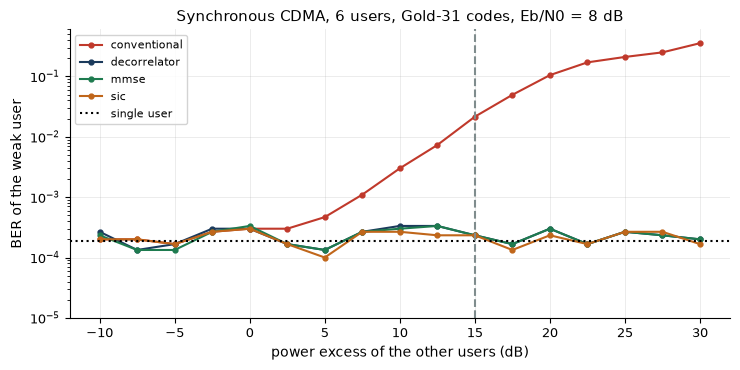

detector,BER at +15 dB
conventional,2.15e-02
decorrelator,2.33e-04
mmse,2.33e-04
sic,2.33e-04


In [13]:
def nearfar_demo(K=6, excess_db=15.0, ebn0_db=8.0):
    Lsf = 31
    Gc = sp.bipolar(sp.gold_codes(5))
    S = Gc[rng.choice(len(Gc), K, replace=False)].T / np.sqrt(Lsf)
    pr = np.arange(-10, 31, 2.5)
    sigma = np.sqrt(1 / (2 * lk.undb(ebn0_db)))
    res = {m: [] for m in ("conventional", "decorrelator", "mmse", "sic")}
    nb = 30000
    for p in pr:
        A = np.r_[1.0, np.full(K - 1, lk.undb(p / 2))]
        bb = rng.choice([-1.0, 1.0], (K, nb))
        y = S @ (A[:, None] * bb) + sigma * rng.standard_normal((Lsf, nb))
        for m in res:
            res[m].append(np.mean(sp.mud_detect(y, S, A, m, sigma ** 2)[0] != bb[0]))
    f, ax = lk.fig((7.5, 3.8))
    for (m, v), col in zip(res.items(), [lk.RED, lk.NAVY, lk.GREEN, lk.ORANGE]):
        ax.semilogy(pr, np.maximum(v, 1e-5), "o-", color=col, ms=3.5, label=m)
    ax.axhline(cl.ber_bpsk(ebn0_db), color="k", ls=":", label="single user")
    ax.axvline(excess_db, color=lk.GRAY, ls="--")
    ax.set_ylim(1e-5, 0.6); ax.set_xlabel("power excess of the other users (dB)"); ax.set_ylabel("BER of the weak user")
    ax.legend(fontsize=8); ax.set_title(f"Synchronous CDMA, {K} users, Gold-31 codes, Eb/N0 = {ebn0_db:g} dB")
    lk.show(f)
    i = np.argmin(np.abs(pr - excess_db))
    lk.table([[m, v[i]] for m, v in res.items()], ["detector", f"BER at +{pr[i]:g} dB"], fmt=".2e")

lk.interact(nearfar_demo, K=lk.islider(6, 2, 12, 1, "users"), excess_db=lk.slider(15, -10, 30, 2.5, "interferer excess (dB)"),
            ebn0_db=lk.slider(8, 2, 14, 0.5, "Eb/N0 (dB)"))

In [14]:
W, R = 1.2288e6, 9600
rows = [["single omni cell, always talking", sp.cdma_capacity(W, R, 7.0)],
        ["+ voice activity 0.4", sp.cdma_capacity(W, R, 7.0, voice_activity=0.4)],
        ["+ other-cell interference f = 0.55", sp.cdma_capacity(W, R, 7.0, 0.4, other_cell=0.55)],
        ["+ three sectors (gain 2.55)", sp.cdma_capacity(W, R, 7.0, 0.4, 2.55, 0.55)]]
lk.table(rows, ["IS-95 uplink (W/R = 128, Eb/I0 = 7 dB)", "users per cell"], fmt=".0f")

"IS-95 uplink (W/R = 128, Eb/I0 = 7 dB)",users per cell
"single omni cell, always talking",27
+ voice activity 0.4,65
+ other-cell interference f = 0.55,42
+ three sectors (gain 2.55),106


**What you should see.** The conventional matched filter's BER climbs rapidly once the other users are a few dB stronger; the decorrelator
and MMSE detectors are almost immune to the power excess (they pay a small noise-enhancement penalty), and SIC actually *benefits* from strong
interferers, which it decodes and subtracts first. The capacity table reproduces the chapter: 26, 65, 42 and about 105 users per cell.

### Try it yourself 4.1
WCDMA voice: $W = 3.84$ Mchip/s, $R = 12.2$ kb/s, $E_b/I_0 = 5$ dB, voice activity 0.5, $f = 0.55$, three sectors (2.55). How many users per cell
does `sp.cdma_capacity` give?

In [16]:
answer_4_1 = None
lk.check("4.1 WCDMA pole capacity (users/cell)", answer_4_1, float(sp.cdma_capacity(3.84e6, 12.2e3, 5.0, 0.5, 2.55, 0.55)), rtol=0.03)

[TODO] 4.1 WCDMA pole capacity (users/cell): not attempted yet: replace the None with your answer

## 5. GPS: the signal below the noise, and acquisition

The L1 C/A signal arrives at about −130 dBm. With a 270 K system temperature, $N_0 = -174.3$ dBm/Hz, so $C/N_0 \approx 44$ dB-Hz and the SNR in a
2 MHz front end is about −19 dB. One code period (1 ms) of correlation lifts it by $10\log_{10}(2\text{ MHz} \times 1\text{ ms}) = 33$ dB. But the
receiver does not know the code phase (1023 chips) or the Doppler (±5 kHz for a static user), so **acquisition** searches a two-dimensional grid:
for each Doppler bin, an FFT circular correlation tests every code phase at once. Non-coherent sums of several 1 ms blocks add sensitivity.

link budget (Chapter 18),
C/N0 for -130 dBm and Tsys 270 K,44.3 dB-Hz
SNR in 2 MHz,-18.7 dB
"post-correlation SNR, 1 ms",14.3 dB
Eb/N0 over a 20 ms bit,27.3 dB


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

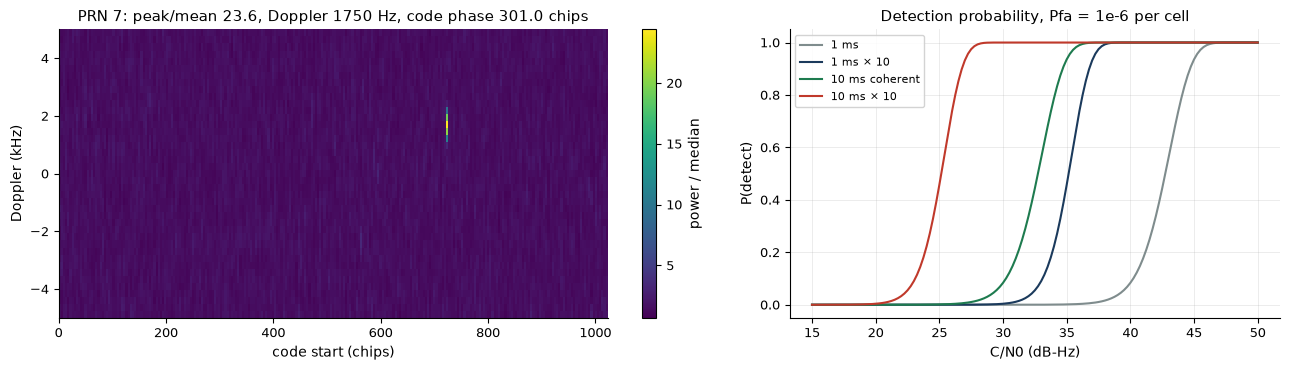

PRN,C/N0 (dB-Hz),peak/mean,detected (> 3.9),Doppler found,true,code phase found,true
7,44,23.6,yes,1750,1750,301.0,301.4
12,42,17.0,yes,-2250,-2200,699.5,700
21,38,6.3,yes,3000,3150,88.0,88
3,46,39.8,yes,-500,-450,989.5,990
30,absent,3.3,no,-4500,-,356.0,-


In [18]:
lk.table([["C/N0 for -130 dBm and Tsys 270 K", f"{-130 - (-228.6 + lk.db(270) + 30):.1f} dB-Hz"],
          ["SNR in 2 MHz", f"{-130 - (-228.6 + lk.db(270) + 30) - lk.db(2e6):.1f} dB"],
          ["post-correlation SNR, 1 ms", f"{-130 - (-228.6 + lk.db(270) + 30) - 30:.1f} dB"],
          ["Eb/N0 over a 20 ms bit", f"{-130 - (-228.6 + lk.db(270) + 30) - lk.db(50):.1f} dB"]], ["link budget (Chapter 18)", ""])
fs = 2.046e6
sats = [dict(prn=7, cn0=44, doppler=1750.0, code_phase=301.4), dict(prn=12, cn0=42, doppler=-2200.0, code_phase=700.0),
        dict(prn=21, cn0=38, doppler=3150.0, code_phase=88.0), dict(prn=3, cn0=46, doppler=-450.0, code_phase=990.0)]
xg, truth = sp.gps_baseband(sats, fs, 0.03, rng=12)

def acq_demo(prn=7, n_noncoh=4, cn0_scale_db=0.0):
    x = xg if cn0_scale_db == 0 else sp.gps_baseband([dict(s, cn0=s["cn0"] + cn0_scale_db) for s in sats], fs, 0.03, rng=12)[0]
    d = np.arange(-5000, 5001, 250.0)
    res = sp.acquire(x, fs, prn, d, 1, n_noncoh)
    g = res["grid"] / np.median(res["grid"])
    f, ax = lk.fig((13, 3.8), 1, 2, gridspec_kw=dict(width_ratios=[1.4, 1]))
    gp = g[:, :g.shape[1] // 8 * 8].reshape(g.shape[0], -1, 8).max(axis=2)     # max-pool 8 samples so the peak is visible
    im = ax[0].imshow(gp, aspect="auto", origin="lower", extent=[0, 1023, d[0] / 1e3, d[-1] / 1e3], cmap="viridis", interpolation="nearest")
    plt.colorbar(im, ax=ax[0], label="power / median"); ax[0].grid(False)
    ax[0].set_xlabel("code start (chips)"); ax[0].set_ylabel("Doppler (kHz)")
    ax[0].set_title(f"PRN {prn}: peak/mean {res['metric']:.1f}, Doppler {res['doppler']:.0f} Hz, code phase {res['code_phase']:.1f} chips")
    c = np.arange(15, 50.1, 0.25)
    for T, K, col, lab in [(1e-3, 1, lk.GRAY, "1 ms"), (1e-3, n_noncoh, lk.NAVY, f"1 ms × {n_noncoh}"),
                           (10e-3, 1, lk.GREEN, "10 ms coherent"), (10e-3, 10, lk.RED, "10 ms × 10")]:
        ax[1].plot(c, sp.acq_pd(c, T, K, pfa=1e-6, loss_db=1.5), color=col, label=lab)
    ax[1].set_xlabel("C/N0 (dB-Hz)"); ax[1].set_ylabel("P(detect)"); ax[1].legend(fontsize=8); ax[1].set_title("Detection probability, Pfa = 1e-6 per cell")
    lk.show(f)
    # threshold on peak/mean for a 1e-3 probability that the whole grid's noise maximum exceeds it
    from scipy.stats import gamma
    thr = gamma.isf(1e-3 / g.size, n_noncoh) / n_noncoh
    rows = []
    for s in sats + [dict(prn=30, cn0=None, doppler=None, code_phase=None)]:
        r_ = sp.acquire(x, fs, s["prn"], d, 1, n_noncoh)
        rows.append([s["prn"], "absent" if s["cn0"] is None else s["cn0"] + cn0_scale_db, r_["metric"],
                     "yes" if r_["metric"] > thr else "no", r_["doppler"],
                     s["doppler"] if s["doppler"] is not None else "-", r_["code_phase"], s["code_phase"] if s["code_phase"] is not None else "-"])
    lk.table(rows, ["PRN", "C/N0 (dB-Hz)", "peak/mean", f"detected (> {thr:.1f})", "Doppler found", "true", "code phase found", "true"],
             fmt={2: ".1f", 6: ".1f"})

lk.interact(acq_demo, prn=lk.choice([7, 12, 21, 3, 30], 7, "PRN to search"), n_noncoh=lk.islider(10, 1, 30, 1, "non-coherent 1 ms blocks"),
            cn0_scale_db=lk.slider(0, -15, 5, 1, "C/N0 change for all satellites (dB)"))

**What you should see.** A single sharp peak in the grid for each satellite that is present, at the right Doppler (within the 250 Hz bin) and
code phase (within half a chip), and a peak/mean of only about 3 for PRN 30, which is absent. The threshold in the table is set so that noise
alone crosses it somewhere in the whole grid only 0.1% of the time (it falls as more blocks are summed, because the noise averages). The 38 dB-Hz
satellite is detected with 10 blocks; drop to 4 blocks, or lower all C/N0 by a few dB, and it sinks into the grid, exactly as the
detection-probability curves predict. Indoors (25 dB-Hz) only long coherent integration plus assistance data work (Chapter 18's "search time" example).

### Try it yourself 5.1
With `sp.acq_pd`, what detection probability does a 1 ms × 10 non-coherent search give at 35 dB-Hz ($P_{fa} = 10^{-6}$, 1.5 dB loss)?

In [20]:
answer_5_1 = None
lk.check("5.1 Pd at 35 dB-Hz, 1 ms x 10", answer_5_1, float(sp.acq_pd(35, 1e-3, 10, 1e-6, 1.5)), atol=0.02)

[TODO] 5.1 Pd at 35 dB-Hz, 1 ms x 10: not attempted yet: replace the None with your answer

## 6. Tracking: DLL, Costas PLL and navigation bits

Acquisition hands each satellite to a tracking channel: a **delay-locked loop** keeps early/prompt/late code replicas aligned (code phase → range),
and a **Costas PLL** (data-insensitive) locks the carrier, assisted by an FLL while the frequency error is large. Once locked, the in-phase prompt
correlator $I_P$ carries the 50 b/s navigation data, 20 code periods per bit.

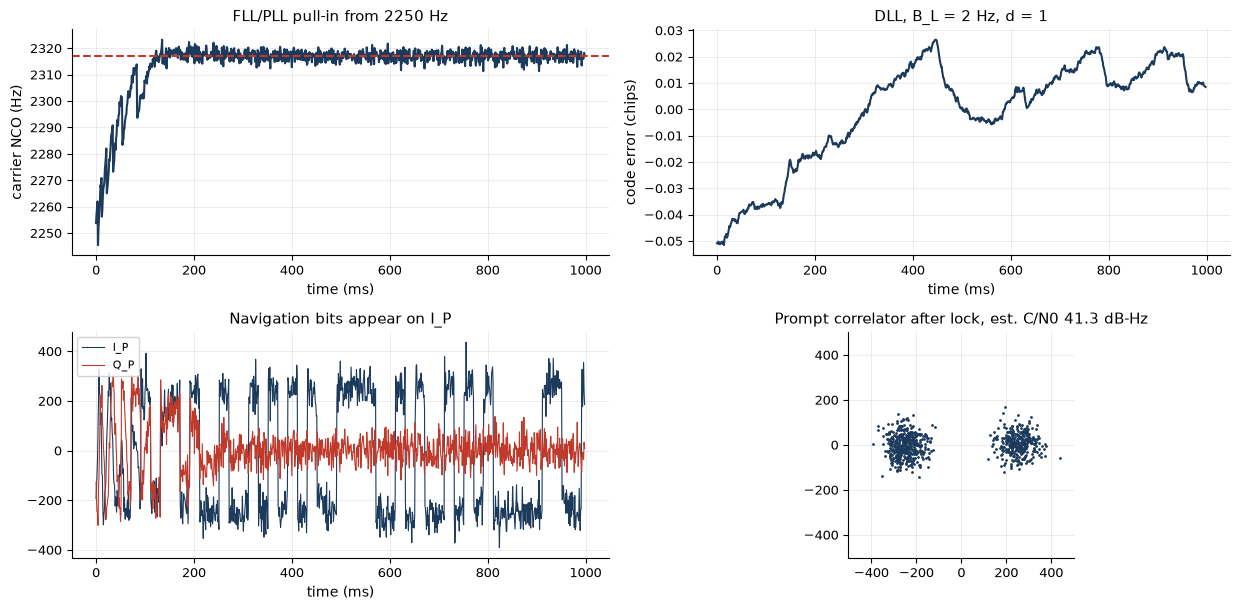

,
Doppler after 1 s (Hz),2317.4 (true 2317.0)
"code error, last 300 ms: mean and rms (chips)","+0.0152, 0.0052 (1.52 m rms)"
C/N0 estimate (dB-Hz),41.3 (true 42)
bit edge offset found (ms),12
navigation bits recovered,"34, 100% correct (polarity -: Costas ambiguity)"


In [22]:
fs_t = 4.092e6
tr = dict(prn=7, cn0=42, doppler=2317.0, code_phase=412.3, bit_offset_ms=7, phase=1.0)
nbits = 60
tbits = rng.choice([-1, 1], nbits)
tr["bits"] = tbits
x1, _ = sp.gps_baseband([tr], fs_t, 1.0, rng=13)
acq = sp.acquire(x1, fs_t, 7, np.arange(-5000, 5001, 250.0), 1, 5)
res = sp.track(x1, fs_t, 7, acq["doppler"], acq["code_phase"], dll_bn=2, pll_bn=15, fll_bn=10)
cr = sp.CA_RATE * (1 + tr["doppler"] / sp.F_L1)
true_cp = (tr["code_phase"] + res["sample"] * cr / fs_t) % 1023
err = (res["code_phase"] - true_cp + 511.5) % 1023 - 511.5
tm = np.arange(len(res["IP"]))
f, ax = lk.fig((12.5, 6.2), 2, 2)
ax[0, 0].plot(tm, res["doppler"], color=lk.NAVY); ax[0, 0].axhline(tr["doppler"], color=lk.RED, ls="--")
ax[0, 0].set_ylabel("carrier NCO (Hz)"); ax[0, 0].set_title(f"FLL/PLL pull-in from {acq['doppler']:.0f} Hz")
ax[0, 1].plot(tm, err, color=lk.NAVY); ax[0, 1].set_ylabel("code error (chips)"); ax[0, 1].set_title("DLL, B_L = 2 Hz, d = 1")
ax[1, 0].plot(tm, res["IP"], color=lk.NAVY, lw=0.8, label="I_P"); ax[1, 0].plot(tm, res["QP"], color=lk.RED, lw=0.8, label="Q_P")
ax[1, 0].legend(fontsize=8); ax[1, 0].set_xlabel("time (ms)"); ax[1, 0].set_title("Navigation bits appear on I_P")
k = tm > 200
ax[1, 1].plot(res["IP"][k], res["QP"][k], ".", ms=2, color=lk.NAVY); ax[1, 1].set_aspect("equal")
lim = 1.15 * np.max(np.abs(np.r_[res["IP"], res["QP"]])); ax[1, 1].set_xlim(-lim, lim); ax[1, 1].set_ylim(-lim, lim)
ax[1, 1].set_title(f"Prompt correlator after lock, est. C/N0 {res['cn0']:.1f} dB-Hz")
for a in ax[0]:
    a.set_xlabel("time (ms)")
lk.show(f)
# bit synchronisation: the 20 ms bit edges are where I_P changes sign; integrate 20 ms between edges
ip = res["IP"][300:]
best = max(range(20), key=lambda o: np.sum(np.abs(ip[o:o + 20 * ((len(ip) - o) // 20)].reshape(-1, 20).sum(axis=1))))
soft = ip[best:best + 20 * ((len(ip) - best) // 20)].reshape(-1, 20).sum(axis=1)
dec = np.sign(soft)
# compare with the transmitted bits, allowing for the Costas 180-degree ambiguity and the unknown start bit
cands = [(np.mean(dec == s * tbits[j:j + len(dec)]), j, s) for j in range(0, nbits - len(dec) + 1) for s in (1, -1)]
agree, j0, sgn = max(cands)
lk.table([["Doppler after 1 s (Hz)", f"{res['doppler'][-1]:.1f} (true {tr['doppler']:.1f})"],
          ["code error, last 300 ms: mean and rms (chips)", f"{np.mean(err[-300:]):+.4f}, {np.std(err[-300:]):.4f} ({np.std(err[-300:]) * 293.05:.2f} m rms)"],
          ["C/N0 estimate (dB-Hz)", f"{res['cn0']:.1f} (true 42)"],
          ["bit edge offset found (ms)", best], ["navigation bits recovered", f"{len(dec)}, {100 * agree:.0f}% correct "
                                                                            f"(polarity {'+' if sgn > 0 else '-'}: Costas ambiguity)"]], ["", ""])

**What you should see.** The FLL drags the carrier from the acquisition bin to the true 2317 Hz in a few tens of ms, then the PLL locks; the code
error converges to near zero with a time constant of a few hundred ms (a 2 Hz loop is slow by design: it averages the noise) and a jitter
of under a hundredth of a chip, a couple of metres (the remaining offset of about 0.015 chip is slow wander of the narrow loop, which
averages out over seconds); the prompt correlator's energy moves entirely onto $I_P$, where the
20 ms data bits are plain to see; the bit decisions match the transmitted bits apart from the 180° Costas ambiguity, which GPS resolves with the
preamble of each subframe. The chapter's precision example: at 45 dB-Hz a 1 Hz DLL with $T = 20$ ms gives 0.004 chips (1.2 m), while the carrier phase
is measured to about a millimetre.

## 7. The position fix, DOP, the ionosphere and jammers

Each pseudorange is $\rho_k = \|\mathbf{s}_k - \mathbf{u}\| + b + \epsilon_k$: four unknowns (position and clock bias $b$), so at least four satellites.
Gauss–Newton iteration from the Earth's centre converges in a handful of steps. Noise is amplified by the geometry: $\sigma_{\text{pos}} \approx
\mathrm{PDOP}\,\sigma_{\text{UERE}}$. Chapter 18's worked example: a receiver in Ottawa, four satellites, a 85 km clock bias.

iteration,position error (m),clock bias estimate (m)
0,"6,367,402.225",0.0
1,"1,447,810.429","1,519,489.0"
2,"65,291.240","148,890.1"
3,132.805,"85,133.6"
4,0.001,"85,000.0"
5,0.000,"85,000.0"
6,0.000,"85,000.0"


,az (deg),el (deg),pseudorange (m)
sat 1,140,24,"23,366,841.1"
sat 2,275,17,"24,084,232.6"
sat 3,74,49,"21,515,671.2"
sat 4,85,76,"20,430,773.1"
PDOP / HDOP / VDOP,4.1,2.6,3.2


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

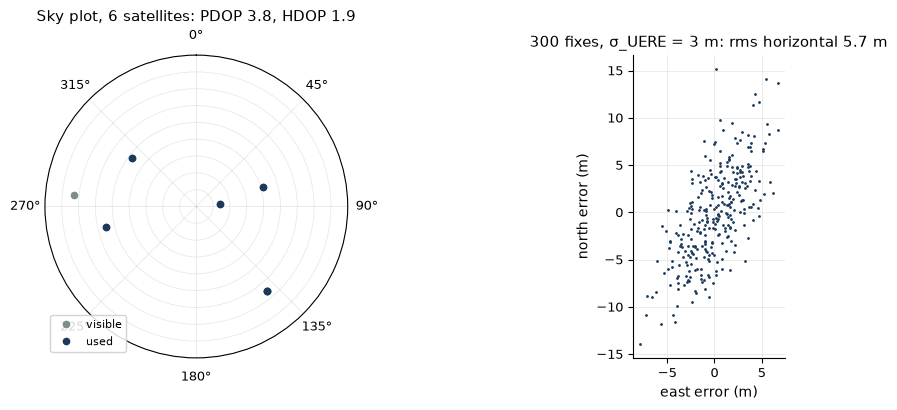

Chapter 18 worked examples,
L1 / L2 iono delay at 50 TECU (m),8.12 / 13.37
iono-free combination error (m),3.41e-13
noise amplification of iono-free (x),2.98
tolerable J/S for tracking (44 -> 28 dB-Hz),32.0 dB
free-space reach of a 10 mW jammer (km),3.2
relativistic clock offset (us/day),38.4


In [24]:
u_true = sp.lla_to_ecef(45.4215, -75.6972, 70.0)
S4 = np.array([[18788, -18772, -98], [-20202, -13309, 10963], [16313, -9282, 18793], [9331, -16171, 18890]]) * 1e3
rho = sp.pseudoranges(S4, u_true, 85_000.0)
xs, hist, _ = sp.solve_position(S4, rho)
az, el = sp.azel(S4.T, u_true)
lk.table([[k, f"{np.linalg.norm(h[:3] - u_true):,.3f}", f"{h[3]:,.1f}"] for k, h in enumerate(hist)],
         ["iteration", "position error (m)", "clock bias estimate (m)"], title="Ottawa fix from four satellites (exact pseudoranges)")
d4 = sp.dop(S4, u_true)
lk.table([[f"sat {i + 1}", f"{az[i]:.0f}", f"{el[i]:.0f}", f"{rho[i]:,.1f}"] for i in range(4)] +
         [["PDOP / HDOP / VDOP", f"{d4['PDOP']:.1f}", f"{d4['HDOP']:.1f}", f"{d4['VDOP']:.1f}"]], ["", "az (deg)", "el (deg)", "pseudorange (m)"])

def fix_demo(sigma_uere=3.0, extra_sats=2):
    t = np.array([3 * 3600.0])
    P = sp.gps_constellation_ecef(t)[:, :, 0]
    azs, els = sp.azel(P.T, u_true)
    vis = np.where(els > 10)[0]
    order_ = vis[np.argsort(-els[vis])]
    sel = order_[:min(len(order_), 4 + extra_sats)]
    Sv = P[sel]
    dd = sp.dop(Sv, u_true)
    lat, lon, _ = sp.ecef_to_lla(u_true)
    en = []
    for _ in range(300):
        rr = sp.pseudoranges(Sv, u_true, 1e4, sigma_uere, rng)
        xx, _, _ = sp.solve_position(Sv, rr, x0=np.r_[u_true + 5e3, 0.0])
        en.append(sp.ecef_to_enu(xx[:3] - u_true, lat, lon))
    en = np.array(en)
    f = plt.figure(figsize=(11, 4.2))
    axp = f.add_subplot(1, 2, 1, projection="polar")
    axp.set_theta_zero_location("N"); axp.set_theta_direction(-1)
    axp.plot(np.radians(azs[vis]), 90 - els[vis], "o", color=lk.GRAY, label="visible")
    axp.plot(np.radians(azs[sel]), 90 - els[sel], "o", color=lk.NAVY, label="used")
    axp.set_rlim(0, 90); axp.set_yticklabels([]); axp.legend(fontsize=8, loc="lower left")
    axp.set_title(f"Sky plot, {len(sel)} satellites: PDOP {dd['PDOP']:.1f}, HDOP {dd['HDOP']:.1f}")
    a2 = f.add_subplot(1, 2, 2)
    a2.plot(en[:, 0], en[:, 1], ".", ms=2, color=lk.NAVY)
    a2.set_aspect("equal"); a2.set_xlabel("east error (m)"); a2.set_ylabel("north error (m)")
    a2.set_title(f"300 fixes, σ_UERE = {sigma_uere:g} m: rms horizontal {np.sqrt(np.mean(en[:, 0] ** 2 + en[:, 1] ** 2)):.1f} m")
    lk.show(f)

lk.interact(fix_demo, sigma_uere=lk.slider(3, 0.3, 10, 0.1, "pseudorange error σ (m)"), extra_sats=lk.islider(2, 0, 6, 1, "satellites beyond four"))

ion1 = sp.iono_delay_m(50, sp.F_L1); ion2 = sp.iono_delay_m(50, sp.F_L2)
J_S = sp.CA_RATE * (10 ** -2.8 - 10 ** -4.4)
d_km = 10 ** ((10 - (-128.5 + lk.db(J_S)) - 32.44 - 20 * np.log10(1575.42)) / 20)
lk.table([["L1 / L2 iono delay at 50 TECU (m)", f"{ion1:.2f} / {ion2:.2f}"],
          ["iono-free combination error (m)", f"{float(sp.iono_free(1000 + ion1, 1000 + ion2)) - 1000:.2e}"],
          ["noise amplification of iono-free (x)", f"{np.hypot(sp.F_L1 ** 2, sp.F_L2 ** 2) / (sp.F_L1 ** 2 - sp.F_L2 ** 2):.2f}"],
          ["tolerable J/S for tracking (44 -> 28 dB-Hz)", f"{lk.db(J_S):.1f} dB"],
          ["free-space reach of a 10 mW jammer (km)", f"{d_km:.1f}"],
          ["relativistic clock offset (us/day)", f"{sp.relativity_offsets()['net_us_day']:.1f}"]], ["Chapter 18 worked examples", ""])

**What you should see.** The Ottawa iteration falls from about 6400 km to kilometres, metres and finally to numerical precision, recovering the
85 000 m clock bias, with PDOP about 4 as in the chapter. In the interactive fix, more satellites lower the DOP and the scatter; the rms horizontal
error is close to HDOP × σ. The table reproduces the ionosphere example (8.12 m at L1, 13.37 m at L2, removed exactly by the iono-free combination at
the price of ×3 noise), the 32 dB jamming margin and the ~3 km reach of a 10 mW jammer, and the famous +38 µs/day relativistic clock offset.

### Try it yourself 7.1
Using `sp.iono_delay_m`, what is the L5 (1176.45 MHz) ionospheric delay in metres for a slant TEC of 50 TECU?

In [26]:
answer_7_1 = None
lk.check("7.1 L5 iono delay at 50 TECU (m)", answer_7_1, float(sp.iono_delay_m(50, sp.F_L5)), atol=0.05)

[TODO] 7.1 L5 iono delay at 50 TECU (m): not attempted yet: replace the None with your answer

## Key takeaways
* m-sequences have ideal two-valued autocorrelation; Gold and Kasami families trade family size against cross-correlation; GPS C/A codes peak at 65/1023.
* Processing gain turns a jammer into weak noise: jamming margin = $G_p - E_b/N_0 - L$.
* The Rake receiver turns resolvable multipath into diversity.
* CDMA is interference-limited: power control or multiuser detection is mandatory; capacity depends on voice activity, sectors and other-cell interference.
* GPS works 20 dB below the noise because correlation over 1–20 ms adds 33–46 dB; acquisition is a 2-D search, tracking is a DLL plus a Costas PLL.
* Position = least squares over pseudoranges; accuracy = DOP × UERE; dual frequency removes the ionosphere.

## Going further (hardware: USRP B200 / GNU Radio)
* **Real GPS with the B200.** Connect an active GPS patch antenna (the B200 can supply bias power via an external bias-tee), tune 1575.42 MHz, and
  record 2 s of IQ at 2.046 or 4.092 MS/s with `gr01_spectrum_iq_capture.py --freq 1575.42e6 --rate 4.092e6`. Load it with `commlib.iq` and run
  `sp.acquire` for PRNs 1–32: you should find the satellites in view (check with any online sky plot for your location and time). Then track one with
  `sp.track` and watch the navigation bits appear. Use the B200's internal TCXO; a GPSDO-locked reference shrinks the Doppler search.
* Projects such as GNSS-SDR implement the full receiver, including ephemeris decoding, if you want to go all the way to a live fix.

## Exercises
1. **(Warm-up)** Verify the balance and run properties of the degree-10 m-sequence.
2. **(Core)** Add a second multipath ray 0.3 chips late to the tracking simulation and measure the DLL bias for $d = 1$ and $d = 0.1$ (the narrow
   correlator).
3. **(Core)** Implement 10 ms coherent integration with data-bit wipe-off (known bits) in `acquire` and acquire a 28 dB-Hz satellite.
4. **(Stretch)** Simulate a LoRa link with `sp.lora_chirp`/`sp.lora_demod` at SF7–SF12 and find the SNR at which the symbol error rate is 1%.

In [28]:
lk.summary()

[good] Lab 25 finished in 5.2 s. Self-checks: 0 passed, 0 failed, 5 still to do.